In [ ]:
from scipy.special import erfc
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def click_probabilities(amplitude):
    mean_photons = np.abs(amplitude)**2

    P_no_click = np.exp(-mean_photons)

    P_click = 1 - P_no_click

    return P_no_click, P_click

In [ ]:
def dolinar_control(alpha, t, dt):
    # Remaining distinguishability
    remaining_overlap = np.exp(-4 * np.abs(alpha)**2 * (1 - t))

    denominator = np.sqrt(1 - remaining_overlap)

    # Avoid division by zero near t = 1
    denominator = max(denominator, 1e-12)

    u = np.abs(alpha) / denominator

    return u * np.sqrt(dt)

In [ ]:
def dolinar_receiver(true_state, alpha, M, store_history=False):
    # Initial probabilities

    P_plus = 0.5
    P_minus = 0.5

    # Time step
    dt = 1 / M

    # Signal amplitude in each time bin
    alpha_bin = alpha * np.sqrt(dt)

    # Store histories
    P_plus_history = []
    P_minus_history = []

    click_history = []
    displacement_history = []

    # Initial sign
    sign = 1

    for k in range(M):

        # Current time
        t = k * dt

        # Calculate Dolinar control amplitude

        control = dolinar_control(alpha, t, dt)

        # Choose displacement direction

        if P_plus >= P_minus:

            beta = -control

        else:

            beta = control

        # Detector amplitudes under hypotheses

        amplitude_plus = (alpha_bin + beta)
        amplitude_minus = (-alpha_bin + beta)

        # Measurement probabilities

        P_no_plus, P_click_plus = (click_probabilities(amplitude_plus))

        P_no_minus, P_click_minus = (click_probabilities(amplitude_minus))

        # Generate the actual measurement

        actual_amplitude = (true_state * alpha_bin+beta)

        P_no_actual, P_click_actual = (click_probabilities(actual_amplitude))

        click = (np.random.random() < P_click_actual)

        # Bayesian update

        if click:

            likelihood_plus = P_click_plus
            likelihood_minus = P_click_minus

        else:

            likelihood_plus = P_no_plus
            likelihood_minus = P_no_minus

        normalization = (likelihood_plus * P_plus + likelihood_minus * P_minus)

        if normalization > 1e-15:

            P_plus = ((likelihood_plus*P_plus)/normalization)
            P_minus = ((likelihood_minus*P_minus)/normalization)

        # Store history

        if store_history:

            P_plus_history.append(P_plus)
            P_minus_history.append(P_minus)
            click_history.append(click)
            displacement_history.append(beta)

    # Final decision

    if P_plus >= P_minus:
        decision = +1

    else:
        decision = -1

    history = {"P_plus": np.array(P_plus_history), "P_minus": np.array(P_minus_history), "clicks": np.array(click_history), "displacements": np.array(displacement_history)}

    return decision, history

In [ ]:
def calculate_dolinar_error(alpha, M=200, n_trials=5000):
    errors = 0

    # Test |+alpha>
    for _ in range(n_trials):

        decision, _ = dolinar_receiver(true_state=+1, alpha=alpha, M=M)

        if decision != +1:
            errors += 1

    # Test |-alpha>
    for _ in range(n_trials):

        decision, _ = dolinar_receiver(true_state=-1, alpha=alpha, M=M)

        if decision != -1:
            errors += 1

    return errors / (2 * n_trials)

In [ ]:
def calculate_dolinar_error(alpha, M=200, n_trials=5000):
    errors = 0

    # Test |+alpha>
    for _ in range(n_trials):

        decision, _ = dolinar_receiver(true_state=+1, alpha=alpha, M=M)

        if decision != +1:
            errors += 1

    # Test |-alpha>
    for _ in range(n_trials):

        decision, _ = dolinar_receiver(true_state=-1, alpha=alpha, M=M)

        if decision != -1:
            errors += 1

    return errors / (2 * n_trials)

In [ ]:
alphas = np.linspace(0.1, 2.0, 25)

P_dolinar = []

for alpha in alphas:
    error = calculate_dolinar_error(alpha, M=200, n_trials=3000)
    P_dolinar.append(error)

P_dolinar = np.array(P_dolinar)

In [ ]:
# Homodyne
P_homodyne = 0.5 * erfc(np.sqrt(2) * alphas)

# Kennedy
P_kennedy = 0.5 * np.exp(-4 * alphas**2)

# Helstrom
P_helstrom = 0.5 * (1-np.sqrt(1-np.exp(-4 * alphas**2)))

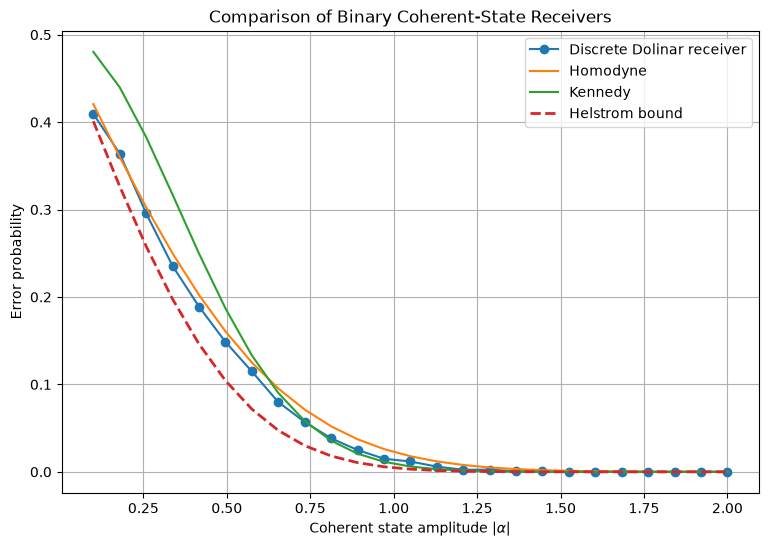

In [9]:
plt.figure(figsize=(9, 6))

plt.plot(alphas, P_dolinar,"o-", label="Discrete Dolinar receiver")
plt.plot(alphas, P_homodyne, label="Homodyne")
plt.plot(alphas, P_kennedy, label="Kennedy")
plt.plot(alphas, P_helstrom, "--", linewidth=2, label="Helstrom bound")

plt.xlabel(r"Coherent state amplitude $|\alpha|$")
plt.ylabel(r"Error probability")
plt.title("Comparison of Binary Coherent-State Receivers")

plt.grid(True, which="both")
plt.legend()
plt.show()